In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings("ignore")

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")

In [3]:
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(exclude='object').columns

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(drop='first'),
            categorical_cols
        ),
        (
            'num',
            StandardScaler(),
            numerical_cols
        )
    ]
)

In [5]:
X_train_encoded = preprocessor.fit_transform(X_train)

In [6]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

In [7]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [8]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
cv_results_lr = cross_validate(
    lr_model,
    X_train_encoded,
    y_train["Churn"],
    cv=skf,
    scoring=scoring
)

cv_results_rf = cross_validate(
    rf_model,
    X_train_encoded,
    y_train["Churn"],
    cv=skf,
    scoring=scoring
)

cv_results_xgb = cross_validate(
    xgb_model,
    X_train_encoded,
    y_train["Churn"],
    cv=skf,
    scoring=scoring
)


In [10]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        cv_results_lr['test_accuracy'].mean(),
        cv_results_rf['test_accuracy'].mean(),
        cv_results_xgb['test_accuracy'].mean()
    ],

    'Precision': [
        cv_results_lr['test_precision'].mean(),
        cv_results_rf['test_precision'].mean(),
        cv_results_xgb['test_precision'].mean()
    ],

    'Recall': [
        cv_results_lr['test_recall'].mean(),
        cv_results_rf['test_recall'].mean(),
        cv_results_xgb['test_recall'].mean()
    ],

    'F1 Score': [
        cv_results_lr['test_f1'].mean(),
        cv_results_rf['test_f1'].mean(),
        cv_results_xgb['test_f1'].mean()
    ],

    'ROC-AUC': [
        cv_results_lr['test_roc_auc'].mean(),
        cv_results_rf['test_roc_auc'].mean(),
        cv_results_xgb['test_roc_auc'].mean()
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803516,0.664771,0.525084,0.586108,0.848321
1,Random Forest,0.800499,0.658913,0.516388,0.578748,0.843056
2,XGBoost,0.792511,0.637583,0.505686,0.563807,0.837089


Logistic Regression outperformed ensemble tree-based methods across cross-validation metrics, suggesting that churn behavior in the dataset is largely driven by stable and interpretable linear relationships rather than highly complex nonlinear interactions.

In [19]:
### Hyper Parameter Tuning 

from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
estimator=lr,
param_grid=param_grid,
scoring='recall',
cv=5,
n_jobs=-1,
verbose=1
)

grid_search.fit(X_train_encoded,y_train["Churn"])

print(grid_search.best_params_)
print("Best Score of recall")
print(grid_search.best_score_)

lr_model = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best Score of recall
0.8053511705685619


In [20]:
lr_model.fit(
    X_train_encoded,
    y_train["Churn"]
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [21]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [22]:
X_test_encoded = preprocessor.transform(X_test)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

def cal_metrics(y_test , y_pred , y_probs):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    
    print("Precision:", precision_score(y_test, y_pred))
    
    print("Recall   :", recall_score(y_test, y_pred))
    
    print("F1 Score :", f1_score(y_test, y_pred))
    
    print("ROC-AUC  :", roc_auc_score(y_test, y_probs))

In [35]:
y_pred = lr_model.predict(X_test_encoded)
y_probs = lr_model.predict_proba(
    X_test_encoded
)[:,1]
cal_metrics(y_test , y_pred , y_probs)

Accuracy : 0.7246273953158269
Precision: 0.4884488448844885
Recall   : 0.7914438502673797
F1 Score : 0.6040816326530613
ROC-AUC  : 0.8334741274638973


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.72      0.74      1409



In [37]:
cm = confusion_matrix(y_test, y_pred)

In [38]:
cm

array([[725, 310],
       [ 78, 296]])

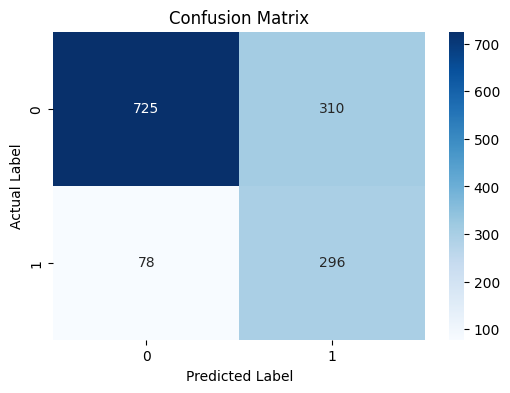

In [39]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [40]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

In [41]:
roc_auc = auc(fpr, tpr)

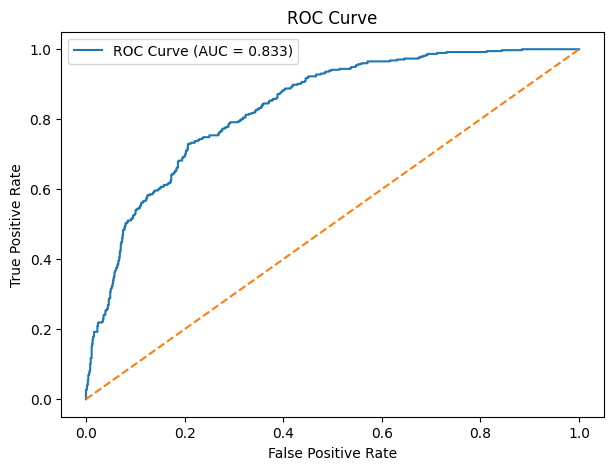

In [42]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve demonstrates strong classification performance, with an AUC score of 0.846 indicating high discriminative capability between churned and retained customers. The steep early rise of the curve suggests that the model effectively captures a significant proportion of churn customers at relatively low false positive rates, making it suitable for proactive retention strategies.




## COEFFICIENT ANALYSIS

In [46]:
feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({

    'Feature': feature_names,

    'Coefficient': lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

In [47]:
coef_df.head(15)

,Feature,Coefficient
35,num__RiskScore,0.882705
28,num__MonthlyCharges,0.198035
33,num__FiberPremiumRisk,0.019270
26,num__SeniorCitizen,0.017819
34,num__SeniorNoSupport,0.000000
32,num__HighValueCustomer,0.000000
31,num__AvgMonthlySpend,0.000000
30,num__TotalServices,0.000000
29,num__TotalCharges,0.000000
1,cat__Partner_Yes,0.000000


In [48]:
coef_df.tail(15)

,Feature,Coefficient
4,cat__MultipleLines_No phone service,0.000000
5,cat__MultipleLines_Yes,0.000000
6,cat__InternetService_Fiber optic,0.000000
7,cat__InternetService_No,0.000000
8,cat__OnlineSecurity_No internet service,0.000000
18,cat__StreamingMovies_No internet service,0.000000
10,cat__OnlineBackup_No internet service,0.000000
11,cat__OnlineBackup_Yes,0.000000
12,cat__DeviceProtection_No internet service,0.000000
13,cat__DeviceProtection_Yes,0.000000


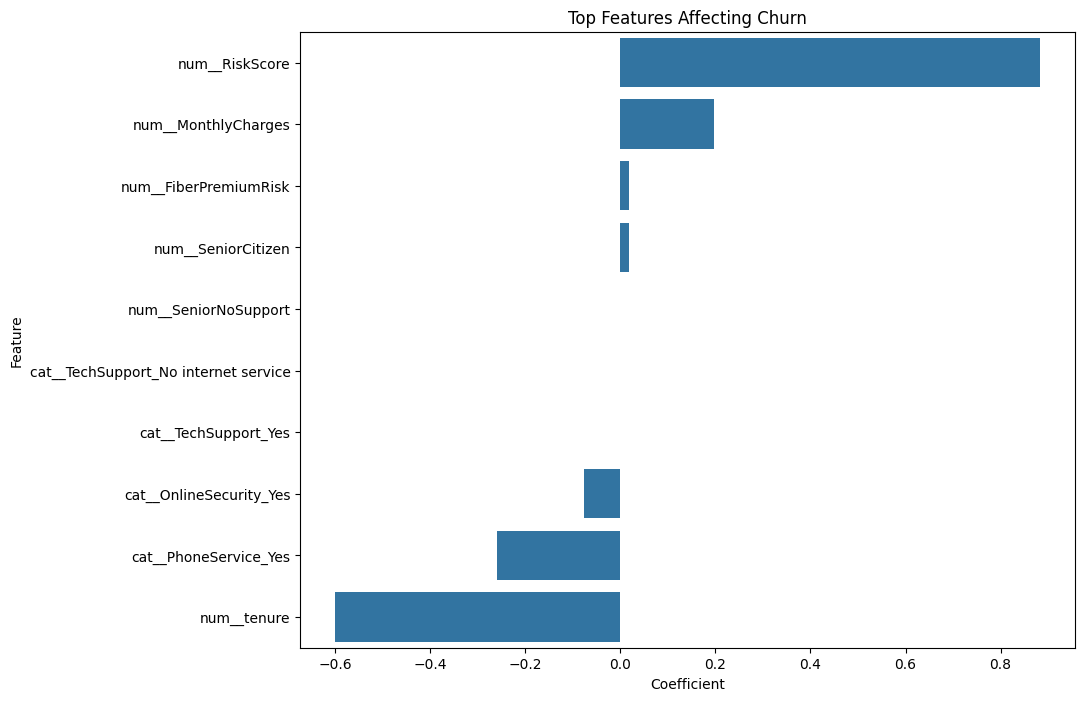

In [49]:
top_features = pd.concat([
    coef_df.head(5),
    coef_df.tail(5)
])

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Features Affecting Churn")

plt.show()

## SHAP EXPLAINABILITY



In [51]:
import shap

In [52]:
explainer = shap.Explainer(
    lr_model,
    X_train_encoded
)

In [53]:
shap_values = explainer(X_test_encoded)

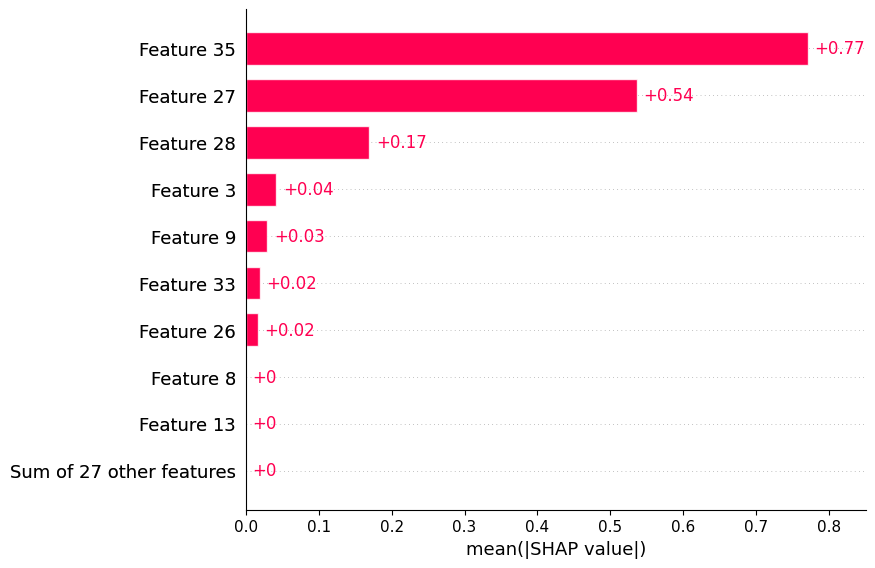

In [54]:
shap.plots.bar(shap_values)

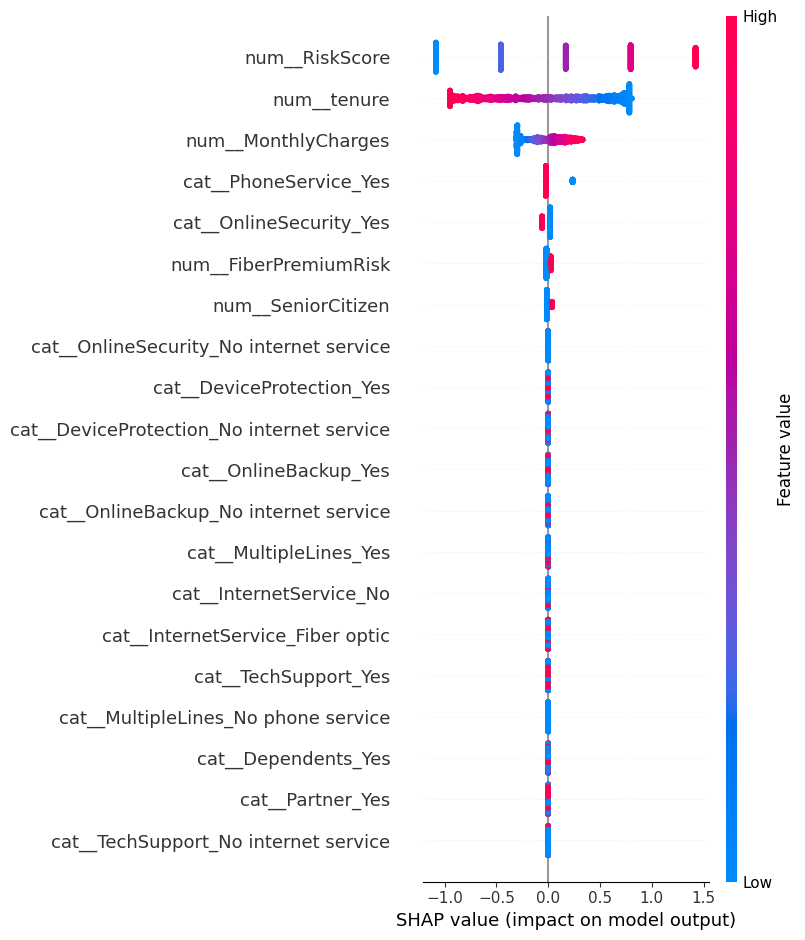

In [55]:
shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=feature_names
)

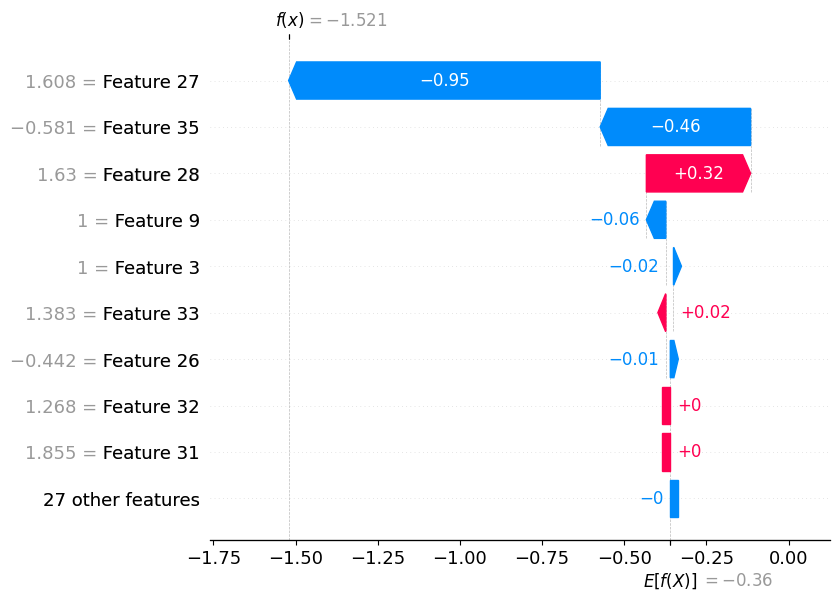

In [56]:
shap.plots.waterfall(
    shap_values[0]
)

## Saving ML Model

In [59]:
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr_model)
])

In [61]:
full_pipeline.fit(
    X_train,
    y_train["Churn"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [62]:
import joblib

joblib.dump(
    full_pipeline,
    "customer_churn_pipeline.pkl"
)

['customer_churn_pipeline.pkl']